In [1]:
%reset -f
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from pyproj import Proj, Transformer
from scipy.interpolate import griddata
import xeofs as xe
from geometry_izzyv1 import grad_sphere
from regression_izzyv1 import linregress_3D
import cartopy.crs as ccrs

crs = ccrs.PlateCarree()
import warnings
import os
from polar_plot_utils import plot_curvilinear_data

warnings.filterwarnings('ignore')
from matplotlib.ticker import MultipleLocator


In [3]:
path = '/Users/iw2g24/PycharmProjects/SSH_project/Data/'
fig_path = '/Users/iw2g24/PycharmProjects/SSH_project/results/NPP_mca/'

ssh_ds = xr.open_dataset(path + 'regridded_ssh2icevel_ds.nc')
wsc_ds = xr.open_dataset(path + 'regridded_wsc2icevel_ds.nc')
oss_ds = xr.open_dataset(path + 'regridded_oss2icevel_ds.nc')
npp_ds = xr.open_dataset(path + 'regridded_to_ice_NPP_ds.nc')
ice_vel_ds = xr.open_dataset(path + 'ice_vels_no_nan_ds.nc')


In [4]:
new_time = pd.to_datetime(npp_ds.time.values).to_period('M').to_timestamp()
npp_ds = npp_ds.assign_coords(time=new_time)

In [5]:
print("ssh_ds variables:", list(ssh_ds.data_vars))
print("wsc_ds variables:", list(wsc_ds.data_vars))
print("oss_ds variables:", list(oss_ds.data_vars))
print("npp_ds variables:", list(npp_ds.data_vars))
print("ice_vel_ds variables:", list(ice_vel_ds.data_vars))


ssh_ds variables: ['SSH_regridded']
wsc_ds variables: ['WSC_regridded']
oss_ds variables: ['OSS_regridded']
npp_ds variables: ['NPP_regridded_to_ice']
ice_vel_ds variables: ['melt']


In [6]:
print("ssh_ds coords:", ssh_ds.coords)
print("wsc_ds coords:", wsc_ds.coords)
print("oss_ds coords:", oss_ds.coords)
print("npp_ds coords:", npp_ds.coords)
print("ice_vel_ds coords:", ice_vel_ds.coords)

ssh_ds coords: Coordinates:
  * time     (time) datetime64[ns] 488B 2002-09-01 2002-12-01 ... 2017-09-01
    lat      (y, x) float64 68MB ...
    lon      (y, x) float64 68MB ...
wsc_ds coords: Coordinates:
  * time     (time) datetime64[ns] 488B 2002-09-01 2002-12-01 ... 2017-09-01
    lat      (y, x) float64 68MB ...
    lon      (y, x) float64 68MB ...
oss_ds coords: Coordinates:
  * time     (time) datetime64[ns] 488B 2002-09-01 2002-12-01 ... 2017-09-01
    lat      (y, x) float64 68MB ...
    lon      (y, x) float64 68MB ...
npp_ds coords: Coordinates:
    lat      (y, x) float64 68MB ...
    lon      (y, x) float64 68MB ...
  * time     (time) datetime64[ns] 472B 2003-03-01 2003-06-01 ... 2017-09-01
ice_vel_ds coords: Coordinates:
    lat      (y, x) float64 68MB ...
    lon      (y, x) float64 68MB ...
  * time     (time) datetime64[ns] 472B 2003-03-01 2003-06-01 ... 2017-09-01


In [7]:
# For WSC dataset
print("SSH start time:", ssh_ds['SSH_regridded'].time.values[2])
print("SSH end time:", ssh_ds['SSH_regridded'].time.values[-1])

# For WSC dataset
print("WSC start time:", wsc_ds['WSC_regridded'].time.values[2])
print("WSC end time:", wsc_ds['WSC_regridded'].time.values[-1])

# For OSC dataset
print("OSS start time:", oss_ds['OSS_regridded'].time.values[2])
print("OSS end time:", oss_ds['OSS_regridded'].time.values[-1])

# For ice vels dataset
print("ice vel start time:", ice_vel_ds['melt'].time.values[0])
print("ice vel end time:", ice_vel_ds['melt'].time.values[-1])

# For NPP dataset
print("NPP start time:", npp_ds['NPP_regridded_to_ice'].time.values[0])
print("NPP end time:", npp_ds['NPP_regridded_to_ice'].time.values[-1])

SSH start time: 2003-03-01T00:00:00.000000000
SSH end time: 2017-09-01T00:00:00.000000000
WSC start time: 2003-03-01T00:00:00.000000000
WSC end time: 2017-09-01T00:00:00.000000000
OSS start time: 2003-03-01T00:00:00.000000000
OSS end time: 2017-09-01T00:00:00.000000000
ice vel start time: 2003-03-01T00:00:00.000000000
ice vel end time: 2017-09-01T00:00:00.000000000
NPP start time: 2003-03-01T00:00:00.000000000
NPP end time: 2017-09-01T00:00:00.000000000


In [8]:
# Function to flip latitude in a dataset
def flip_lat(ds):
    if 'y' in ds.dims:
        return ds.sel(y=slice(None, None, -1))
    else:
        print('y dimension not found in dataset.')
        return ds

# Apply to each dataset
ssh_ds = flip_lat(ssh_ds)
wsc_ds = flip_lat(wsc_ds)
oss_ds = flip_lat(oss_ds)
#npp_ds = flip_lat(npp_ds)
ice_vel_ds = flip_lat(ice_vel_ds)


In [9]:
print("SSH latitudes (first 10):", ssh_ds['lat'].values[:2])
print("WSC longitudes (first 10):", wsc_ds['lat'].values[:2])
print("OSS latitudes (first 10):", oss_ds['lat'].values[:2])
print("NPP longitudes (first 10):", npp_ds['lat'].values[:2])
print("ice vel latitudes (first 10):", ice_vel_ds['lat'].values[:2])



SSH latitudes (first 10): [[-54.5936238  -54.60503583 -54.61644464 ... -54.61653376 -54.60512498
  -54.59371297]
 [-54.60503577 -54.61645242 -54.62786585 ... -54.627955   -54.6165416
  -54.60512498]]
WSC longitudes (first 10): [[-54.5936238  -54.60503583 -54.61644464 ... -54.61653376 -54.60512498
  -54.59371297]
 [-54.60503577 -54.61645242 -54.62786585 ... -54.627955   -54.6165416
  -54.60512498]]
OSS latitudes (first 10): [[-54.5936238  -54.60503583 -54.61644464 ... -54.61653376 -54.60512498
  -54.59371297]
 [-54.60503577 -54.61645242 -54.62786585 ... -54.627955   -54.6165416
  -54.60512498]]
NPP longitudes (first 10): [[-54.5936238  -54.60503583 -54.61644464 ... -54.61653376 -54.60512498
  -54.59371297]
 [-54.60503577 -54.61645242 -54.62786585 ... -54.627955   -54.6165416
  -54.60512498]]
ice vel latitudes (first 10): [[-54.59353464 -54.60494663 -54.6163554  ... -54.61644452 -54.60503577
  -54.5936238 ]
 [-54.60494663 -54.61636324 -54.62777663 ... -54.62786579 -54.61645242
  -54.6050

In [ ]:
# model = xe.cross.MCA(n_modes=22, standardize=True)
model = xe.cross.MCA(n_modes=5, standardize=True)

# sub_ssh_ds = ssh_ds['SSH_regridded'].isel(time=slice(2, None))
# sub_wsc_ds = wsc_ds['WSC_regridded'].isel(time=slice(2, None))
# model.fit(sub_ssh_ds, sub_wsc_ds, dim='time')

# sub_wsc_ds = wsc_ds['WSC_regridded'].isel(time=slice(2, None))
# model.fit(sub_wsc_ds, npp_ds['NPP_regridded_to_ice'], dim='time')

# sub_oss_ds = oss_ds['OSS_regridded'].isel(time=slice(2, None))
# model.fit(sub_oss_ds, npp_ds['NPP_regridded_to_ice'], dim='time')
#
sub_ssh_ds = ssh_ds['SSH_regridded'].isel(time=slice(2, None))
model.fit(sub_ssh_ds, npp_ds['NPP_regridded_to_ice'], dim='time')

#model.fit( ice_vel_ds['melt'], npp_ds['NPP_regridded_to_ice'], dim='time')

comps1, comps2 = model.components()  # Singular vectors (spatial patterns)
scores1, scores2 = model.scores()  # Expansion coefficients (temporal patterns)
s1 = scores1.values;
s2 = scores2.values
c1 = comps1.values;
c2 = comps2.values

#how can you change from using cross.MCA to calling the subplots PCA1, PCA2, PCA3 etc ...
r_pears = [];
p_pears = []
r_spear = [];
p_spear = []
for m in range(1, 5):
    x = scores1.sel(mode=m)
    y = scores2.sel(mode=m)
    r, p = scipy.stats.pearsonr(x, y)
    r_pears.append(np.round(r, 2));
    p_pears.append(np.round(p, 2))
    r, p = scipy.stats.spearmanr(x, y)
    r_spear.append(np.round(r, 2));
    p_spear.append(np.round(p, 2))


sq_cov_frac = model.squared_covariance_fraction()
scf = sq_cov_frac.values
cum_sum = np.cumsum(scf)
print('Cumulative sum of squares:', cum_sum)
print('Squared covariance fraction:', scf)
print(type(cum_sum))
print(len(cum_sum))
mode_percent = []
for i in range(len(cum_sum)):
    if i == 0:
        each_mode_percent = float(cum_sum[i])
        mode_percent.append(each_mode_percent)
    else:
        each_mode_percent = float(cum_sum[i] - cum_sum[i - 1])
        mode_percent.append(each_mode_percent)
print('PCA fraction', mode_percent)


fig = plt.figure(figsize=(12, 10))

for i in range(0, 4):
    j = 3 * i + 1  # a = 2*(i+1) + i - 1

    plt.subplot(4, 3, j)
    scores1.sel(mode=i + 1).plot(label='SSH')
    scores2.sel(mode=i + 1).plot(label='NPP')
    plt.title("r = {}, PCA = {:.3f}".format(r_spear[i], mode_percent[i]))
    plt.xlabel('Year');
    plt.ylabel('PC' + str(int(i + 1)))
    plt.xticks(rotation=30)
    plt.legend()

    plt.subplot(4, 3, j + 1)
    comps1.sel(mode=i + 1).plot()
    plt.title('SSH')

    plt.subplot(4, 3, j + 2)
    comps2.sel(mode=i + 1).plot()
    plt.title('NPP')

fig.tight_layout()

#fig.savefig(path + 'results/MCA_output_' + gridtype + '_seas.png')
# compute squared covariance fraction (equivalent to explained variance in PCA)
# sq_cov_frac = model.squared_covariance_fraction()
# scf = sq_cov_frac.values
# cum_sum = np.cumsum(scf)
# print('Cumulative sum of squares:', cum_sum)
# print('Squared covariance fraction:', scf)
# print(type(cum_sum))
# print(len(cum_sum))
# mode_percent = []
# for i in range(len(cum_sum)):
#     if i == 0:
#         each_mode_percent = float(cum_sum[i])
#         mode_percent.append(each_mode_percent)
#     else:
#         each_mode_percent = float(cum_sum[i] - cum_sum[i - 1])
#         mode_percent.append(each_mode_percent)
# print('PCA fraction', mode_percent)

In [13]:
#save the figure
#fig.savefig(fig_path + 'ssh_npp.png')

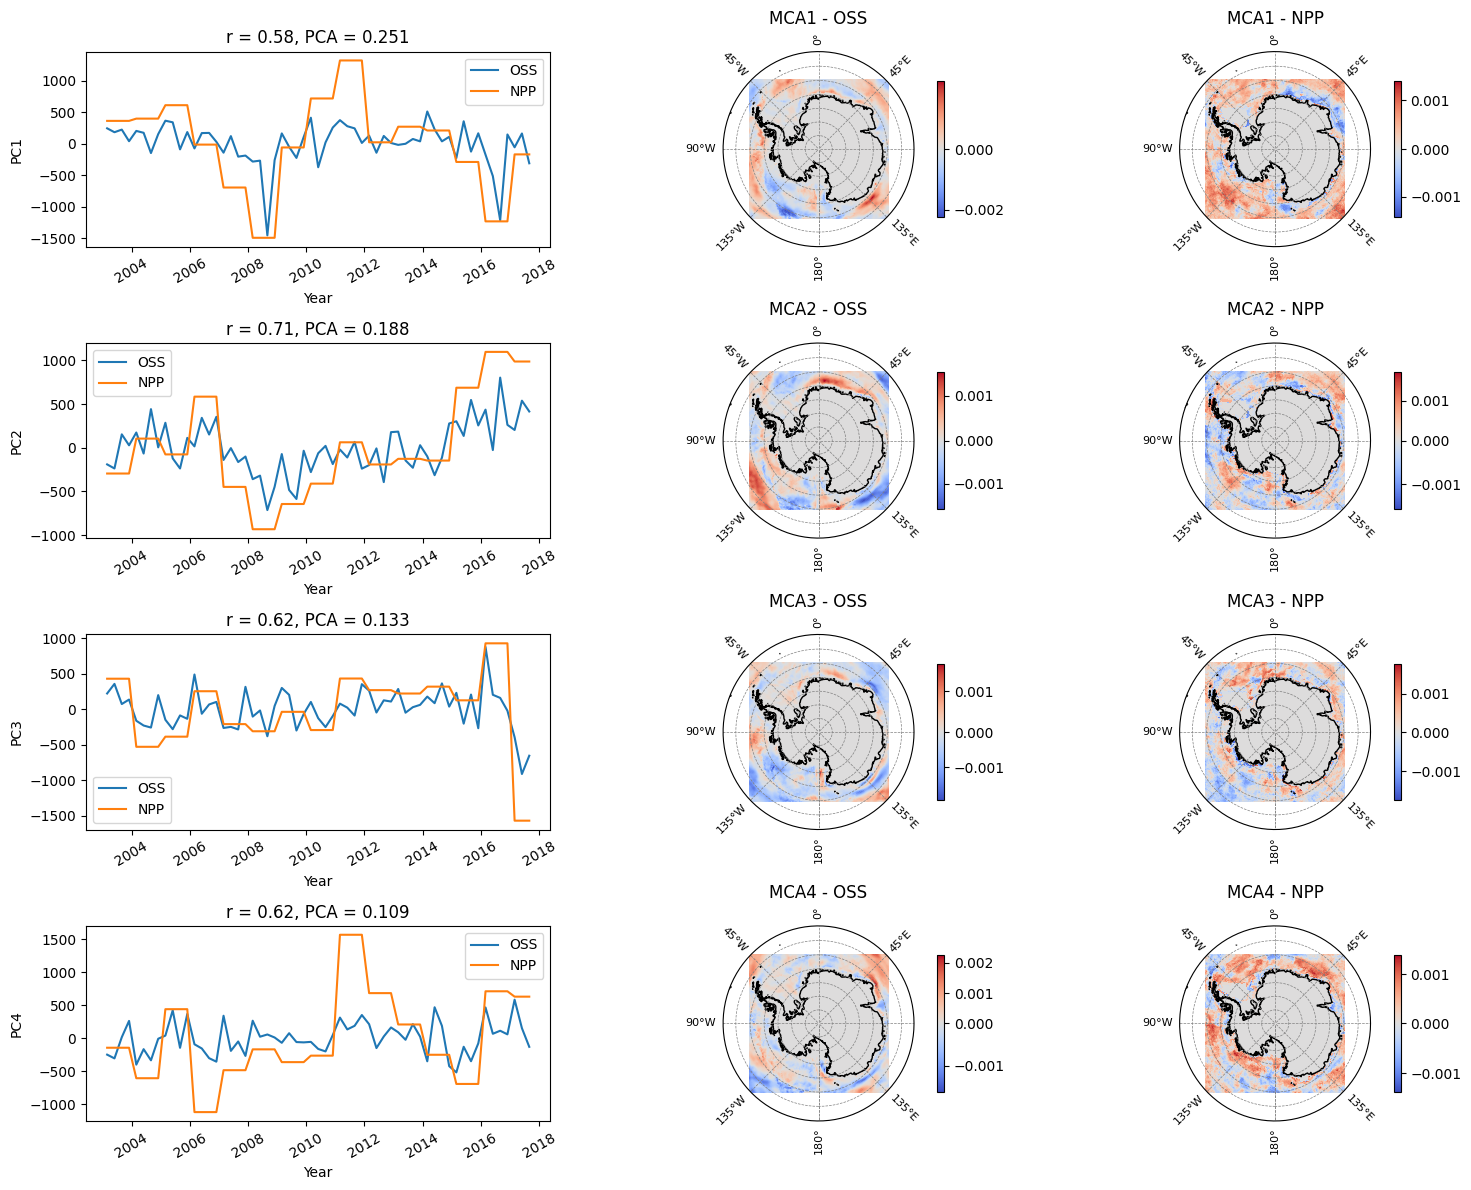

In [14]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats
from matplotlib.gridspec import GridSpec

# Assuming comps1 and comps2 are already defined and contain your data
comp1 = comps1.sel(mode=1)
comp2 = comps2.sel(mode=1)
lon = comp1.lon.values
lat = comp1.lat.values
data1 = comp1.values
data2 = comp2.values

# Create the figure and GridSpec
fig = plt.figure(figsize=(15, 12))  # Adjust figure size to accommodate bigger columns
gs = GridSpec(4, 3, figure=fig, width_ratios=[2, 2, 2])  # Column widths: 1 for column 1, 2 for columns 2 and 3

# Loop over modes 1 to 4 and plot results
for i in range(0, 4):
    j = 3 * i  # Column position for scores plots

    # Plot scores (time series) in 1st column
    ax1 = fig.add_subplot(gs[i, 0])  # Use gs to position the subplot in the 1st column
    scores1.sel(mode=i + 1).plot(ax=ax1, label='SSH')
    scores2.sel(mode=i + 1).plot(ax=ax1, label='NPP')
    ax1.set_title("r = {}, PCA = {:.3f}".format(r_spear[i], mode_percent[i]))
    ax1.set_xlabel('Year')
    ax1.set_ylabel('PC' + str(int(i + 1)))
    ax1.tick_params(axis='x', rotation=30)
    ax1.legend()

    # Create circular plot for SSH in 2nd column
    ax2 = fig.add_subplot(gs[i, 1], projection=ccrs.SouthPolarStereo())  # 2nd column (bigger)
    comp1 = comps1.sel(mode=i + 1)
    lon = comp1.lon.values
    lat = comp1.lat.values
    data1 = comp1.values
    plot_curvilinear_data(ax2, data1, lon, lat, "MCA" + str(i + 1) + " - SSH")

    # Create circular plot for WSC in 3rd column
    ax3 = fig.add_subplot(gs[i, 2], projection=ccrs.SouthPolarStereo())  # 3rd column (bigger)
    comp2 = comps2.sel(mode=i + 1)
    data2 = comp2.values
    plot_curvilinear_data(ax3, data2, lon, lat, "MCA" + str(i + 1) + " - NPP")

# Adjust layout to prevent overlap
fig.tight_layout()
plt.show()


In [15]:
#save the figure
#fig.savefig(fig_path + 'ssh_npp_curviplot.png')

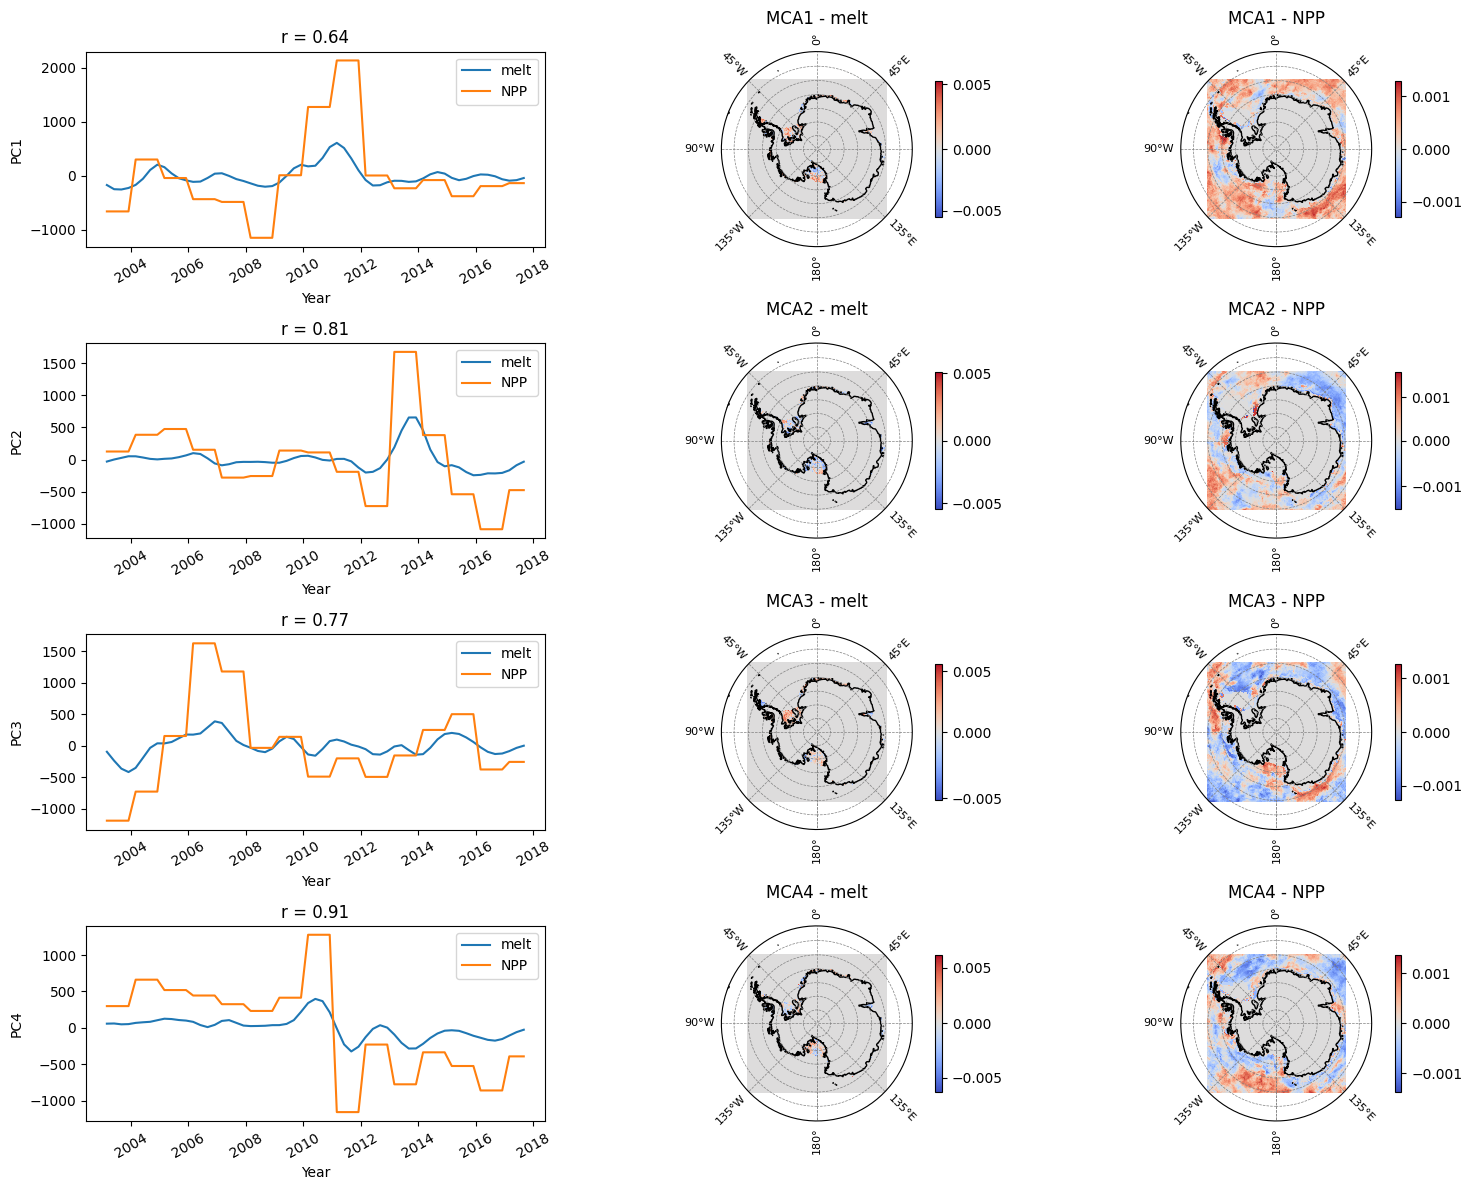

In [74]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib import colors
import scipy.stats
from matplotlib.gridspec import GridSpec

# Assuming comps1 and comps2 are already defined and contain your data
comp1 = comps1.sel(mode=1)
comp2 = comps2.sel(mode=1)
lon = comp1.lon.values
lat = comp1.lat.values
data1 = comp1.values
data2 = comp2.values

# Initialize lists for correlation coefficients
r_pears = []
p_pears = []
r_spear = []
p_spear = []

# Calculate correlation coefficients
for m in range(1, 5):
    x = scores1.sel(mode=m)
    y = scores2.sel(mode=m)
    r, p = scipy.stats.pearsonr(x, y)
    r_pears.append(np.round(r, 2))
    p_pears.append(np.round(p, 2))
    r, p = scipy.stats.spearmanr(x, y)
    r_spear.append(np.round(r, 2))
    p_spear.append(np.round(p, 2))

# Create the figure and GridSpec
fig = plt.figure(figsize=(15, 12))  # Adjust figure size to accommodate bigger columns
gs = GridSpec(4, 3, figure=fig, width_ratios=[2, 2, 2])  # Column widths: 1 for column 1, 2 for columns 2 and 3

# Loop over modes 1 to 4 and plot results
for i in range(0, 4):
    j = 3 * i  # Column position for scores plots

    # Plot scores (time series) in 1st column
    ax1 = fig.add_subplot(gs[i, 0])  # Use gs to position the subplot in the 1st column
    scores1.sel(mode=i + 1).plot(ax=ax1, label='SSH')
    scores2.sel(mode=i + 1).plot(ax=ax1, label='WSC')
    ax1.set_title('r = ' + str(r_spear[i]))
    ax1.set_xlabel('Year')
    ax1.set_ylabel('PC' + str(int(i + 1)))
    ax1.tick_params(axis='x', rotation=30)
    ax1.legend()

    # Create circular plot for SSH in 2nd column
    ax2 = fig.add_subplot(gs[i, 1], projection=ccrs.SouthPolarStereo())  # 2nd column (bigger)
    comp1 = comps1.sel(mode=i + 1)
    lon = comp1.lon.values
    lat = comp1.lat.values
    data1 = comp1.values
    plot_curvilinear_data(ax2, data1, lon, lat, "MCA" + str(i + 1) + " - SSH")

    # Create circular plot for WSC in 3rd column
    ax3 = fig.add_subplot(gs[i, 2], projection=ccrs.SouthPolarStereo())  # 3rd column (bigger)
    comp2 = comps2.sel(mode=i + 1)
    data2 = comp2.values
    plot_curvilinear_data(ax3, data2, lon, lat, "MCA" + str(i + 1) + " - WSC")

# Adjust layout to prevent overlap
fig.tight_layout()
plt.show()
